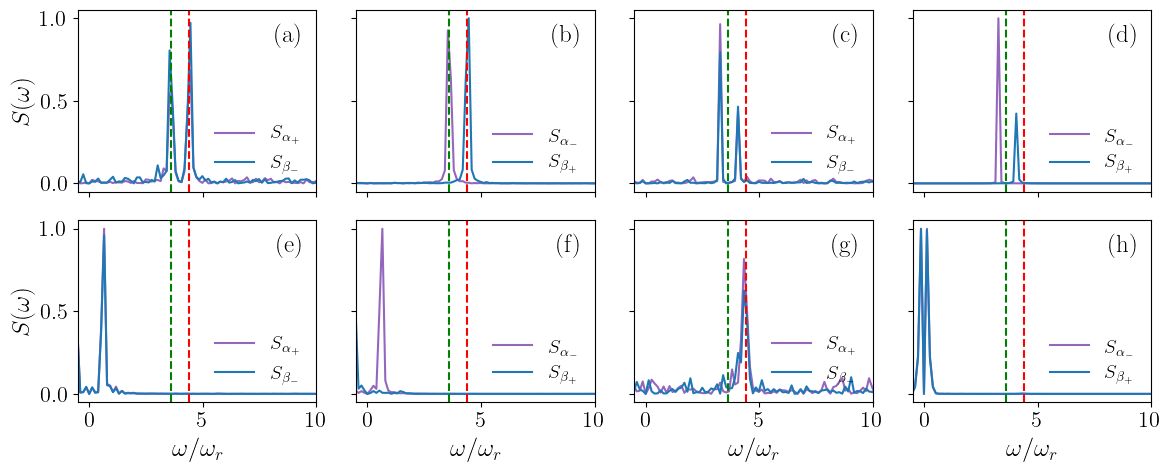

In [1]:
import numpy as np

data_path = r"Figure_21_data.npz"

data = np.load(data_path)

freq = data["freq"]
omega_r = data["omega_r"]

S_ap = data["S_ap"]
S_am = data["S_am"]
S_bp = data["S_bp"]
S_bm = data["S_bm"]

S_ap1 = data["S_ap1"]
S_am1 = data["S_am1"]
S_bp1 = data["S_bp1"]
S_bm1 = data["S_bm1"]

S_ap2 = data["S_ap2"]
S_am2 = data["S_am2"]
S_bp2 = data["S_bp2"]
S_bm2 = data["S_bm2"]

S_ap3 = data["S_ap3"]
S_am3 = data["S_am3"]
S_bp3 = data["S_bp3"]
S_bm3 = data["S_bm3"]

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker

# ============================================================
# PRL STYLE
# ============================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",

    # --- Base font ---
    "font.size": 16,

    # --- Axis labels (x,y) ---
    "axes.labelsize": 18,

    # --- Tick labels ---
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # --- Axes style ---
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# --------------------------------------------------
# 2x4 spectra layout: 8 panels
# Each panel: a pair of spectra
# --------------------------------------------------
spectra_pairs = [
    [(S_ap,  S_bm),  (S_am,  S_bp),
     (S_ap1, S_bm1), (S_am1, S_bp1)],
    [(S_ap2, S_bm2), (S_am2, S_bp2),
     (S_ap3, S_bm3), (S_am3, S_bp3)]
]

# Matching legend labels for each panel
legend_labels = [
    [(r'$S_{\alpha_+}$',  r'$S_{\beta_-}$'),
     (r'$S_{\alpha_-}$',  r'$S_{\beta_+}$'),
     (r'$S_{\alpha_+}$', r'$S_{\beta_-}$'),
     (r'$S_{\alpha_-}$', r'$S_{\beta_+}$')],

    [(r'$S_{\alpha_+}$', r'$S_{\beta_-}$'),
     (r'$S_{\alpha_-}$', r'$S_{\beta_+}$'),
     (r'$S_{\alpha_+}$', r'$S_{\beta_-}$'),
     (r'$S_{\alpha_-}$', r'$S_{\beta_+}$')]
]
panel_labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)']

# --------------------------------------------------
# Define consistent colors: blue (C0) and red (C1)
# --------------------------------------------------
color1 = 'C0'  # blue
color2 = 'C4'  # red

# legend_labels = [r'$S_{\alpha_+ / \beta_+}$', r'$S_{\alpha_- / \beta_-}$']

# --------------------------------------------------
# Create figure
# --------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
x = freq / omega_r
label_index = 0

# Font sizes
tick_size = 16
label_size = 18
panel_label_size = 18
legend_size = 16

for i in range(2):
    for j in range(4):

        ax = axes[i, j]
        S1, S2 = spectra_pairs[i][j]

        # Plot S1 (blue) and S2 (red)
        line1, = ax.plot(x, S2, color=color2, lw=1.5)
        line2, = ax.plot(x, S1, color=color1, lw=1.5)

        # Vertical reference lines
        ax.axvline(3.61, color='g', lw=1.5, linestyle='--')
        ax.axvline(4.4,  color='r', lw=1.5, linestyle='--')

        ax.set_xlim([-0.5, 10])
        ax.tick_params(direction='out', labelsize=tick_size)

        ax.text(
            0.95, 0.93,
            panel_labels[label_index],
            transform=ax.transAxes,
            fontsize=panel_label_size,
            ha='right',   # align to right edge
            va='top'      # align from top
        )

        # Axis labels only on bottom row and first column
        if i == 1:
            ax.set_xlabel(r'$\omega/\omega_r$', fontsize=label_size)
        if j == 0:
            ax.set_ylabel(r'$S(\omega)$', fontsize=label_size)

        ax.legend([line1, line2],
          legend_labels[i][j],
          loc='lower right',
          fontsize=14,
          frameon=False)

        label_index += 1

plt.tight_layout()
plt.show()